# 15. 확신도를 쓴다: 애매한 날을 빼면 나아지는가

## Overview

12번에서 분류 모델의 방향 적중률이 **62.8%** 로 나왔습니다(찍기 기준선 51.1%).
그런데 그때 확률은 **0.5를 넘느냐 마느냐**로만 썼습니다. 확률이 0.51인 날과
0.92인 날을 똑같이 취급한 것입니다.

여기서는 그 확률의 **크기**를 씁니다. 0.5에서 멀수록 모델이 확신하는 날이니,
애매한 날을 빼고 확신하는 날만 골랐을 때 적중률과 이득이 오르는지 봅니다.

**11번의 실패가 배경입니다.** 11번에서는 회귀 모델의 예측 크기("많이 오른다고
할수록 잘 맞히겠지")로 날을 골라봤는데 실패했습니다. 확률은 다를 수 있습니다:
회귀 예측 크기는 변동성이 큰 날에 그냥 크게 나오지만, 분류 확률은 학습 데이터에서
같은 상황이 얼마나 일관되게 한 방향이었는지를 담기 때문입니다.

## 이어받는 것

| 노트북 | 이어받는 결론 |
|---|---|
| 11 | 회귀 예측 크기로 날 고르기는 실패: 최선이 -0.01로 노이즈 이하 |
| 12 | 분류 모델 62.8%, 확률은 냈지만 0.5 임계값만 사용 |
| 13 | 쓸 자리는 출하 시점 결정: 전체 19품목 +2.85% |
| 14 | 저장 10일 이상만 남기면 +2.07%, 중간지대 4품목 +4.41% |

## 이 문서에서 쓰는 말

13·14번에서 쓰던 용어를 쉬운 말로 바꿉니다. 뜻은 같습니다.

| 예전 표현 | 이 문서 | 뜻 |
|---|---|---|
| H1 이득 % | **더 받은 돈** | 그냥 오늘 팔았을 때보다 얼마나 더 벌었나 |
| 손익분기 보관비 % | **창고비 한도** | 창고비가 이보다 비싸면 손해 |
| 미루는 비율 % | **창고에 넣는 비율** | 며칠치를 안 팔고 미뤘나 |

핵심은 한 문장입니다.

> **창고에 넣어서 더 번 돈보다 창고비가 싸면 남는다.**

퍼센트가 둘이라 헷갈리기 쉬운데, **원 단위로는 같은 숫자**입니다. 더 번 만큼까지가
쓸 수 있는 창고비이기 때문입니다. 퍼센트가 갈리는 건 나누는 대상이 달라서입니다:
더 받은 돈은 **출하 전량**으로 나누고, 창고비 한도는 **창고에 넣은 물량**으로
나눕니다. 6절에 원 단위 표를 같이 둡니다.

## 목차

1. 준비: 12번 재현
2. 가설
3. 현황: 확률이 어디에 몰려 있나
4. H1 검증: 확신할수록 잘 맞히는가
5. H3 검증: 회귀 크기로 자르면 다른가 (11번 대조)
6. H2 검증: 돈으로 환산하면
7. 정직한 평가: 임계값을 미리 정할 수 있는가
8. 결론

## 1. 준비: 12번 재현

12번·13번·14번과 **똑같은 피처·폴드·하이퍼파라미터**를 씁니다. 달라지는 건
확률을 어떻게 쓰느냐뿐입니다. 회귀 모델도 같이 학습합니다: 5절에서 11번 방식과
대조하는 데 필요합니다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import (HistGradientBoostingClassifier,
                             HistGradientBoostingRegressor)

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
# unicode_minus 는 set_style 뒤에 둡니다: seaborn 이 rcParams 를 되돌려
# 눈금의 음수 부호가 AppleGothic 에 없는 U+2212 로 찍히고 경고가 납니다.
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())

# 14번과 동일한 저장 가능 일수. 6절에서 실행 가능 품목을 가르는 데 씁니다.
STORAGE = {
    "시금치": 7, "상추": 10, "배추": 30, "양배추": 50, "무": 45, "감자": 45,
    "양파": 165, "얼갈이배추": 10, "알배기배추": 20, "깻잎": 7, "미나리": 7,
    "열무": 7, "파": 7, "풋고추": 14, "브로콜리": 14, "고구마": 60,
    "생강": 90, "깐마늘(국산)": 30, "피마늘": 180,
}
가능품목 = [k for k, v in STORAGE.items() if v >= 10]      # 7거래일 ≈ 10 달력일
중간지대 = ["상추", "얼갈이배추", "풋고추", "배추"]
print(f"{len(df):,}행 | 품목 {len(items)}개")
print(f"실행 가능 {len(가능품목)}품목 | 중간지대 {len(중간지대)}품목")

24,078행 | 품목 19개
실행 가능 14품목 | 중간지대 4품목


In [2]:
H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]

b = df.copy()
b["_logp"] = np.log(b.price_kg_avg)


def g(c):
    return b.groupby("item")[c]


b["y"] = g("_logp").shift(-H) - b._logp
b["오름"] = b.y > 0
b["미래가격"] = g("price_kg_avg").shift(-H)
for lag in (1, 2, 3, 5, 10, 20):
    b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    b[f"dev{w}"] = b._logp - g("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    b[f"vol{w}"] = g("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy = b.price_date.dt.dayofyear
b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                           .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
b["item_code"] = pd.Categorical(b.item, categories=items).codes
feat = b.dropna(subset=["y", "미래가격"]).reset_index(drop=True)

FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev", "item_code"])
CAT = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

t0 = time.time()
out = []
for k, (s, e) in enumerate(FOLDS):
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = feat[feat.price_date < s - EMBARGO]
    te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
    reg = HistGradientBoostingRegressor(
        loss="absolute_error", categorical_features=CAT, early_stopping=False,
        random_state=42, **PARAMS).fit(tr[FEATS], tr.y)
    clf = HistGradientBoostingClassifier(
        categorical_features=CAT, early_stopping=False,
        random_state=42, **PARAMS).fit(tr[FEATS], tr.오름)
    t = te[["item", "price_date", "month", "y", "오름",
            "price_kg_avg", "미래가격"]].copy()
    t["폴드"] = k
    t["회귀예측"] = reg.predict(te[FEATS])
    t["오를확률"] = clf.predict_proba(te[FEATS])[:, 1]
    out.append(t)
r = pd.concat(out).reset_index(drop=True)

r["오른다예측"] = r.오를확률 > 0.5
r["방향맞음"] = r.오른다예측 == r.오름
r["확신도"] = (r.오를확률 - 0.5).abs()          # 0.5에서 떨어진 거리
r["회귀크기"] = r.회귀예측.abs()                 # 11번이 썼던 기준

print(f"준비 완료 ({time.time()-t0:.0f}초, {len(r):,}일)")
print(f"12번 재현 확인: 방향 적중률 {r.방향맞음.mean()*100:.1f}%  (12번 62.8%)")

준비 완료 (27초, 15,762일)
12번 재현 확인: 방향 적중률 62.8%  (12번 62.8%)


## 2. 가설

| 가설 | 내용 | 맞다면 보여야 할 것 |
|---|---|---|
| **H1** | 확신할수록 잘 맞힌다 | 확률 구간별 적중률이 U자: 0.5 근처가 낮고 양 끝이 높음 |
| **H2** | 확신하는 날만 쓰면 건당 수익성이 오른다 | 임계값을 올릴수록 **창고비 한도**가 상승 |
| **H3** | 11번의 실패와 다르다 | 같은 커버리지에서 확률 컷 적중률 > 회귀 크기 컷 |

**H1이 왜 말이 되나**: 분류 모델의 확률은 학습 데이터에서 비슷한 상황이 얼마나
일관되게 한 방향이었는지를 담습니다. 0.92라는 건 "그런 날은 거의 다 올랐다"는
뜻이니, 그 자체가 신뢰도 정보입니다.

**H1이 틀릴 수도 있는 이유**: 부스팅 모델의 확률은 보정(calibration)이 안 된
경우가 흔합니다. 확률이 높다고 실제 빈도가 그만큼 높지 않을 수 있습니다.

### 함정 두 개

**커버리지 상충.** 확신하는 날만 고르면 행동하는 날이 줄어듭니다. 적중률이
올라도 더 받은 돈은 되레 줄 수 있으니, 적중률과 커버리지를 항상 같이 놓고 봅니다.
그래서 H2의 판정 지표를 **더 받은 돈**이 아니라 **창고비 한도**(더 받은 돈 ÷
창고에 넣는 비율)로 잡았습니다: 창고에 넣은 물량 한 건당 얼마나 남는지를 재는
값이라 창고에 적게 넣어도 공정하게 비교됩니다.

**룩어헤드.** 결과를 다 보고 임계값을 고르면 04·11번이 경계한 그 실수입니다.
4~6절은 **탐색**이라 전 구간을 보고, 7절에서 **이전 폴드로만 임계값을 정해
다음 폴드에 적용**합니다. 진짜 성적은 7절입니다.

### 미리 적어두는 예측

작업 전 예측: **적중률이 62.8%에서 2~3%p 오르는 데 그치고, 70%는 어렵다.**

## 3. 현황: 확률이 어디에 몰려 있나

H1을 재기 전에 확인할 게 있습니다. **확률이 전부 0.5 근처에 몰려 있으면**
아무리 잘라봐야 남는 날이 없습니다. 분포부터 봅니다.

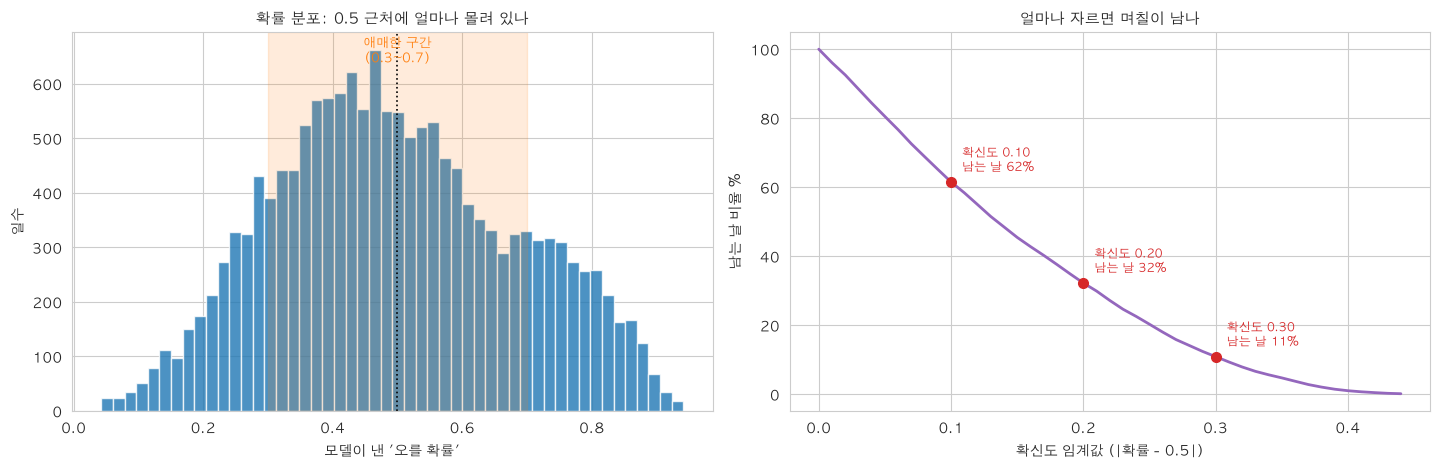

확률 범위: 0.043 ~ 0.942
  전체                     15,762일 (100.0%)
  0.45~0.55 (매우 애매)       3,074일 ( 19.5%)
  0.30~0.70 (애매)         10,682일 ( 67.8%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))

ax = axes[0]
ax.hist(r.오를확률, bins=50, color="tab:blue", alpha=0.8)
ax.axvline(0.5, color="black", ls=":", lw=1.2)
ax.axvspan(0.3, 0.7, color="tab:orange", alpha=0.15)
ax.text(0.5, ax.get_ylim()[1] * 0.92, "애매한 구간\n(0.3~0.7)",
        ha="center", fontsize=9, color="tab:orange")
ax.set_xlabel("모델이 낸 '오를 확률'")
ax.set_ylabel("일수")
ax.set_title("확률 분포: 0.5 근처에 얼마나 몰려 있나", fontsize=11)

ax = axes[1]
thr_grid = np.arange(0, 0.45, 0.01)
cov = [(r.확신도 >= t).mean() * 100 for t in thr_grid]
ax.plot(thr_grid, cov, lw=2, color="tab:purple")
for t in (0.10, 0.20, 0.30):
    c = (r.확신도 >= t).mean() * 100
    ax.plot([t], [c], "o", color="tab:red", ms=7)
    ax.annotate(f"확신도 {t:.2f}\n남는 날 {c:.0f}%", (t, c), fontsize=8.5,
                xytext=(8, 8), textcoords="offset points", color="tab:red")
ax.set_xlabel("확신도 임계값 (|확률 - 0.5|)")
ax.set_ylabel("남는 날 비율 %")
ax.set_title("얼마나 자르면 며칠이 남나", fontsize=11)

plt.tight_layout()
plt.show()

print(f"확률 범위: {r.오를확률.min():.3f} ~ {r.오를확률.max():.3f}")
for lo, hi, lb in ((0.0, 1.0, "전체"), (0.45, 0.55, "0.45~0.55 (매우 애매)"),
                   (0.3, 0.7, "0.30~0.70 (애매)")):
    n = ((r.오를확률 >= lo) & (r.오를확률 <= hi)).sum()
    print(f"  {lb:22s} {n:6,}일 ({n/len(r)*100:5.1f}%)")

## 4. H1 검증: 확신할수록 잘 맞히는가

두 가지로 봅니다.

- **구간별**: 확률을 10개 구간으로 나눠 각 구간의 실제 적중률을 잽니다. U자가
  나와야 합니다.
- **누적**: 확신도 임계값을 올려가며 남은 날의 적중률을 잽니다. 실제로 쓸 때의
  모습에 가깝습니다.

In [4]:
bins = np.arange(0, 1.01, 0.1)
r["확률구간"] = pd.cut(r.오를확률, bins, include_lowest=True)
구간 = r.groupby("확률구간", observed=True).agg(
    일수=("방향맞음", "size"),
    적중률=("방향맞음", lambda s: s.mean() * 100),
    실제상승률=("오름", lambda s: s.mean() * 100),
)
구간["구간중앙"] = [i.mid for i in 구간.index]
구간["일수비중"] = (구간.일수 / len(r) * 100).round(1)
display(구간[["일수", "일수비중", "적중률", "실제상승률"]].round(1))
print("적중률: 그 구간에서 방향을 맞힌 비율")
print("실제상승률: 그 구간에서 실제로 오른 비율 (보정이 잘 됐다면 구간 중앙값과 비슷해야 합니다)")

,일수,일수비중,적중률,실제상승률
확률구간,,,,
"(-0.001, 0.1]",87,0.6,86.2,13.8
"(0.1, 0.2]",616,3.9,69.8,30.2
"(0.2, 0.3]",1724,10.9,67.7,32.3
"(0.3, 0.4]",2747,17.4,64.7,35.3
"(0.4, 0.5]",3301,20.9,57.1,42.9
"(0.5, 0.6]",2765,17.5,52.3,52.3
"(0.6, 0.7]",1869,11.9,60.5,60.5
"(0.7, 0.8]",1640,10.4,72.1,72.1
"(0.8, 0.9]",940,6.0,78.4,78.4


적중률: 그 구간에서 방향을 맞힌 비율
실제상승률: 그 구간에서 실제로 오른 비율 (보정이 잘 됐다면 구간 중앙값과 비슷해야 합니다)


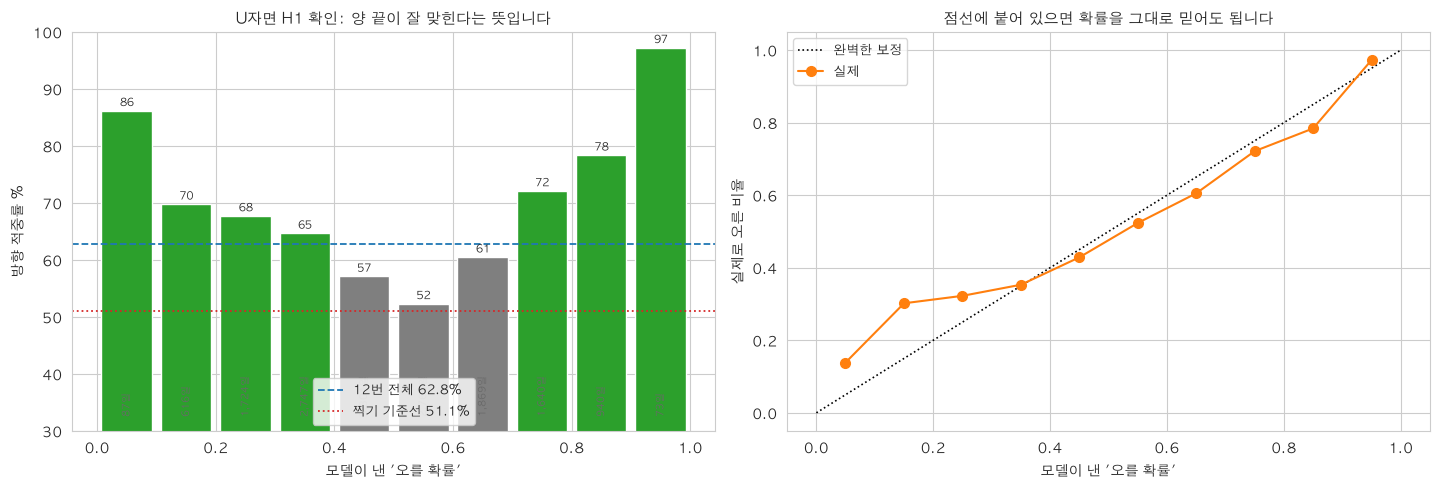

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5))

# (1) 구간별 적중률: U자가 나오는가
ax = axes[0]
cols = ["tab:green" if v >= 62.8 else "tab:gray" for v in 구간.적중률]
ax.bar(구간.구간중앙, 구간.적중률, width=0.085, color=cols)
ax.axhline(62.8, color="tab:blue", ls="--", lw=1.3, label="12번 전체 62.8%")
ax.axhline(51.1, color="tab:red", ls=":", lw=1.3, label="찍기 기준선 51.1%")
for x, y, n in zip(구간.구간중앙, 구간.적중률, 구간.일수):
    ax.text(x, y + 0.8, f"{y:.0f}", ha="center", fontsize=8)
    ax.text(x, 33, f"{n:,}일", ha="center", fontsize=7, color="dimgray", rotation=90)
ax.set_ylim(30, 100)
ax.set_xlabel("모델이 낸 '오를 확률'")
ax.set_ylabel("방향 적중률 %")
ax.set_title("U자면 H1 확인: 양 끝이 잘 맞힌다는 뜻입니다", fontsize=11)
ax.legend(fontsize=9, loc="lower center")

# (2) 보정: 예측 확률 vs 실제 상승 빈도
ax = axes[1]
ax.plot([0, 1], [0, 1], "k:", lw=1.2, label="완벽한 보정")
ax.plot(구간.구간중앙, 구간.실제상승률 / 100, "o-", color="tab:orange", ms=7,
        label="실제")
ax.set_xlabel("모델이 낸 '오를 확률'")
ax.set_ylabel("실제로 오른 비율")
ax.set_title("점선에 붙어 있으면 확률을 그대로 믿어도 됩니다", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
def 컷성적(기준컬럼, 임계값들, 라벨):
    rows = []
    for t in 임계값들:
        sel = r[r[기준컬럼] >= t]
        rows.append({
            "임계값": t,
            "남는 날": len(sel),
            "커버리지 %": len(sel) / len(r) * 100,
            "적중률 %": sel.방향맞음.mean() * 100 if len(sel) else np.nan,
        })
    out = pd.DataFrame(rows)
    out["기준"] = 라벨
    return out


THR = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
cut = 컷성적("확신도", THR, "분류 확률")
cut["12번 대비 %p"] = (cut["적중률 %"] - cut.loc[0, "적중률 %"]).round(1)
display(cut[["임계값", "남는 날", "커버리지 %", "적중률 %", "12번 대비 %p"]]
        .round({"커버리지 %": 1, "적중률 %": 1, "12번 대비 %p": 1}))
print("임계값 0.20 은 '확률이 0.7 이상이거나 0.3 이하인 날'과 같습니다.")

,임계값,남는 날,커버리지 %,적중률 %,12번 대비 %p
0,0.00,15762,100.0,62.8,0.0
1,0.05,12688,80.5,65.2,2.4
2,0.10,9696,61.5,67.8,4.9
3,0.15,7163,45.4,70.4,7.5
4,0.20,5080,32.2,72.1,9.3
5,0.25,3196,20.3,74.6,11.7
6,0.30,1716,10.9,76.5,13.7
7,0.35,746,4.7,78.7,15.8
8,0.40,160,1.0,91.2,28.4


임계값 0.20 은 '확률이 0.7 이상이거나 0.3 이하인 날'과 같습니다.


## 5. H3 검증: 회귀 크기로 자르면 다른가

11번에서는 **회귀 모델의 예측 크기**로 날을 골랐다가 실패했습니다. 확률이 정말
다른 정보인지 확인하려면 **같은 커버리지**에서 나란히 놓아야 공정합니다.

예를 들어 확률 컷이 40%의 날을 남긴다면, 회귀 크기 컷도 상위 40%만 남겨
적중률을 비교합니다.

,커버리지 %,확신도 임계값,확률 컷 적중률 %,회귀 크기 컷 적중률 %,차이 %p
0,100.0,0.00,62.8,62.8,0.0
1,80.5,0.05,65.2,64.2,1.0
2,61.5,0.10,67.8,66.6,1.2
3,45.4,0.15,70.4,69.3,1.0
4,32.2,0.20,72.1,72.2,-0.1
5,20.3,0.25,74.6,75.6,-1.0
6,10.9,0.30,76.5,79.1,-2.6
7,4.7,0.35,78.7,80.4,-1.7
8,1.0,0.40,91.2,90.6,0.6


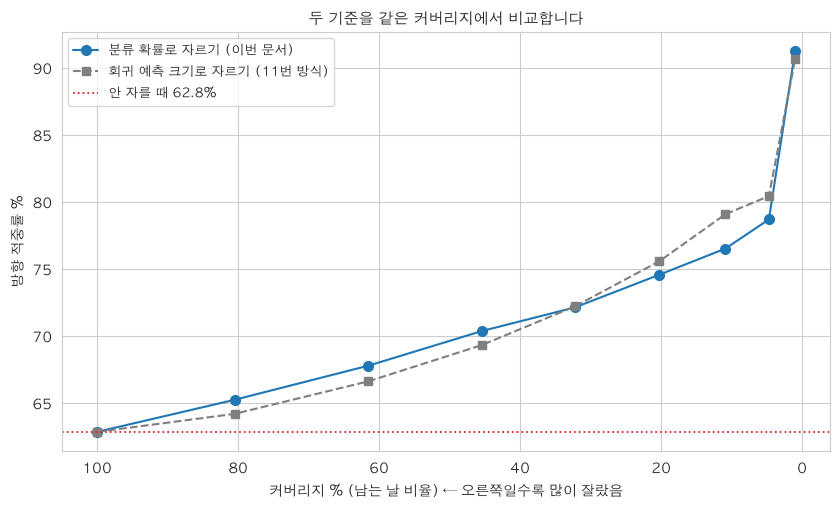

In [7]:
rows = []
for t in THR:
    sel_p = r[r.확신도 >= t]
    cov = len(sel_p) / len(r)
    if len(sel_p) == 0:
        continue
    # 같은 커버리지가 되도록 회귀 크기의 분위수를 맞춥니다
    q = r.회귀크기.quantile(1 - cov)
    sel_r = r[r.회귀크기 >= q]
    rows.append({
        "커버리지 %": cov * 100,
        "확신도 임계값": t,
        "확률 컷 적중률 %": sel_p.방향맞음.mean() * 100,
        "회귀 크기 컷 적중률 %": sel_r.방향맞음.mean() * 100,
    })
h3 = pd.DataFrame(rows)
h3["차이 %p"] = (h3["확률 컷 적중률 %"] - h3["회귀 크기 컷 적중률 %"]).round(1)
display(h3.round({"커버리지 %": 1, "확률 컷 적중률 %": 1,
                  "회귀 크기 컷 적중률 %": 1, "차이 %p": 1}))

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(h3["커버리지 %"], h3["확률 컷 적중률 %"], "o-", ms=7,
        color="tab:blue", label="분류 확률로 자르기 (이번 문서)")
ax.plot(h3["커버리지 %"], h3["회귀 크기 컷 적중률 %"], "s--", ms=6,
        color="tab:gray", label="회귀 예측 크기로 자르기 (11번 방식)")
ax.axhline(r.방향맞음.mean() * 100, color="tab:red", ls=":", lw=1.3,
           label=f"안 자를 때 {r.방향맞음.mean()*100:.1f}%")
ax.invert_xaxis()
ax.set_xlabel("커버리지 % (남는 날 비율) ← 오른쪽일수록 많이 잘랐음")
ax.set_ylabel("방향 적중률 %")
ax.set_title("두 기준을 같은 커버리지에서 비교합니다", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. H2 검증: 돈으로 환산하면

13·14번의 **출하 시점 결정**에 그대로 얹습니다. 규칙만 한 줄 바뀝니다.

| | 13·14번 | 이 문서 |
|---|---|---|
| 창고에 넣는 날 | 오를 확률 > 0.5 | 오를 확률 > 0.5 **그리고 확신도 ≥ 임계값** |
| 나머지 날 | 오늘 판다 | 오늘 판다 |

애매한 날은 **아무것도 안 하는 것**(오늘 판다)이 기본 동작입니다.

판정 지표는 **창고비 한도**입니다. 더 받은 돈만 보면 창고에 적게 넣는 임계값이
무조건 불리해서 비교가 안 됩니다.

In [8]:
def 출하성과(s, thr):
    # 확신도 thr 이상이면서 오른다고 본 날만 창고에 넣습니다. '항상 오늘 판다' 대비.
    창고 = (s.오를확률 > 0.5) & (s.확신도 >= thr)
    실현 = np.where(창고, s.미래가격.values, s.price_kg_avg.values)
    더받은돈 = (실현.mean() / s.price_kg_avg.mean() - 1) * 100
    비율 = 창고.mean()
    return 더받은돈, 비율 * 100, (더받은돈 / 비율 if 비율 > 0 else np.nan)


rows = []
for label, sel in (("전체 19품목", items), ("실행 가능 14품목", 가능품목),
                   ("중간지대 4품목", 중간지대)):
    s = r[r.item.isin(sel)]
    for t in THR:
        더받은돈, 넣는비율, 한도 = 출하성과(s, t)
        rows.append({"대상": label, "확신도 임계값": t, "더 받은 돈 %": 더받은돈,
                     "창고에 넣는 비율 %": 넣는비율, "창고비 한도 %": 한도})
gain = pd.DataFrame(rows)
display(gain.pivot(index="확신도 임계값", columns="대상",
                   values=["더 받은 돈 %", "창고비 한도 %"]).round(2))
print("임계값 0.00 이 13·14번 값입니다: 전체 +2.85% · 실행가능 +2.07% · 중간지대 +4.41%")

더 받은 돈 %                    창고비 한도 %                 
대상      실행 가능 14품목 전체 19품목 중간지대 4품목 실행 가능 14품목 전체 19품목 중간지대 4품목
확신도 임계값                                                        
0.00          2.07    2.85     4.41       4.80    6.15     8.68
0.05          1.99    2.85     4.24       5.86    7.67     9.84
0.10          1.80    2.72     3.94       7.05    9.48    11.26
0.15          1.64    2.50     3.66       8.38   11.19    13.51
0.20          1.47    2.09     3.39      10.12   12.44    16.18
0.25          1.07    1.50     2.44      10.47   13.28    15.83
0.30          0.70    1.01     1.66      12.18   15.69    18.09
0.35          0.25    0.44     0.60      11.16   16.18    16.54
0.40          0.02    0.12     0.02       9.66   26.76     7.68

임계값 0.00 이 13·14번 값입니다: 전체 +2.85% · 실행가능 +2.07% · 중간지대 +4.41%


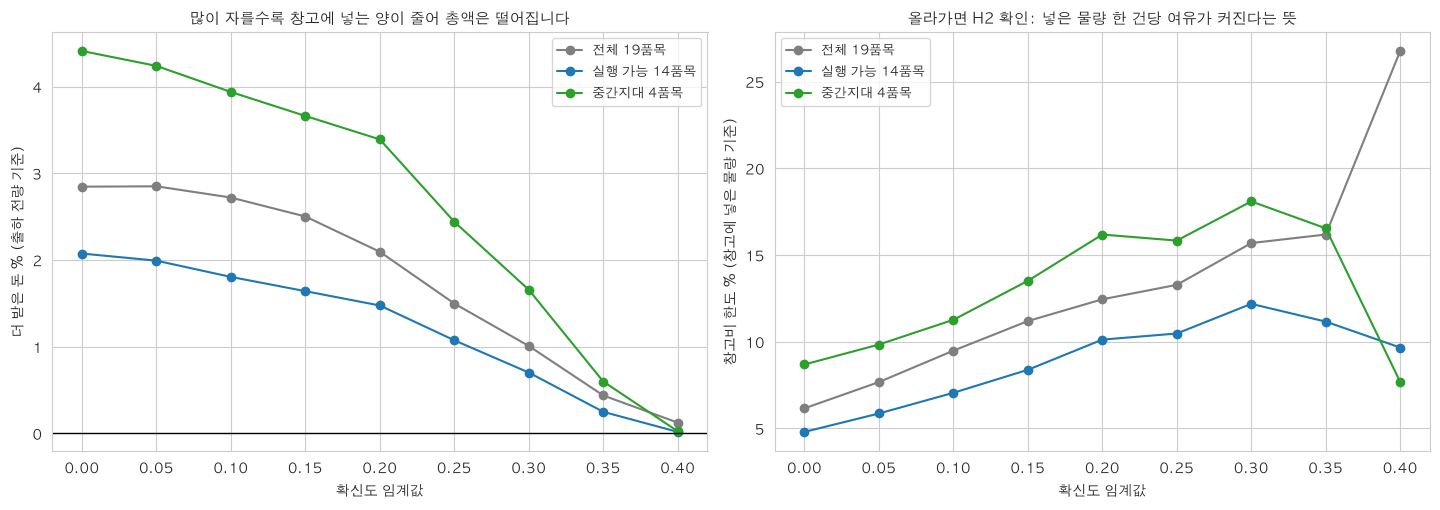

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
COLS = {"전체 19품목": "tab:gray", "실행 가능 14품목": "tab:blue",
        "중간지대 4품목": "tab:green"}

ax = axes[0]
for lb, c in COLS.items():
    s = gain[gain.대상 == lb]
    ax.plot(s["확신도 임계값"], s["더 받은 돈 %"], "o-", ms=6, color=c, label=lb)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("확신도 임계값")
ax.set_ylabel("더 받은 돈 % (출하 전량 기준)")
ax.set_title("많이 자를수록 창고에 넣는 양이 줄어 총액은 떨어집니다", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
for lb, c in COLS.items():
    s = gain[gain.대상 == lb]
    ax.plot(s["확신도 임계값"], s["창고비 한도 %"], "o-", ms=6, color=c, label=lb)
ax.set_xlabel("확신도 임계값")
ax.set_ylabel("창고비 한도 % (창고에 넣은 물량 기준)")
ax.set_title("올라가면 H2 확인: 넣은 물량 한 건당 여유가 커진다는 뜻", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 원 단위로 보면

퍼센트 두 개가 헷갈리니 **1,000만 원어치 출하한다**고 놓고 원으로 바꿉니다.
비교할 숫자는 둘뿐입니다: **더 번 돈**과 **창고비**.

In [10]:
기준액 = 1000  # 만원. 오늘 전량을 팔았다면 받았을 금액
rows = []
for label in ["실행 가능 14품목", "중간지대 4품목"]:
    for t in (0.00, 0.20):
        s = gain[(gain.대상 == label) & (gain["확신도 임계값"] == t)].iloc[0]
        넣은돈 = 기준액 * s["창고에 넣는 비율 %"] / 100
        번돈 = 기준액 * s["더 받은 돈 %"] / 100
        rows.append({
            "대상": label,
            "방식": "다 넣기" if t == 0 else "확신한 날만",
            "창고에 넣은 물건값 (만원)": 넣은돈,
            "더 번 돈 (만원)": 번돈,
            "창고비가 이보다 비싸면 손해 (만원)": 번돈,
            "넣은 물건값 대비 %": s["창고비 한도 %"],
        })
display(pd.DataFrame(rows).round(1).to_string(index=False))
print(f"\n출하 전량을 오늘 팔았다면 {기준액:,}만 원입니다.")
print("'더 번 돈'과 '창고비 한도'는 원 단위로는 같은 숫자입니다: 번 만큼까지 쓸 수 있어서입니다.")

'        대상     방식  창고에 넣은 물건값 (만원)  더 번 돈 (만원)  창고비가 이보다 비싸면 손해 (만원)  넣은 물건값 대비 %\n실행 가능 14품목   다 넣기            432.5        20.7                  20.7          4.8\n실행 가능 14품목 확신한 날만            145.8        14.7                  14.7         10.1\n  중간지대 4품목   다 넣기            507.9        44.1                  44.1          8.7\n  중간지대 4품목 확신한 날만            209.6        33.9                  33.9         16.2'


출하 전량을 오늘 팔았다면 1,000만 원입니다.
'더 번 돈'과 '창고비 한도'는 원 단위로는 같은 숫자입니다: 번 만큼까지 쓸 수 있어서입니다.


## 7. 정직한 평가: 임계값을 미리 정할 수 있는가

4~6절은 전 구간을 보고 임계값을 고른 것이라 **룩어헤드**입니다. 실제로는 오늘
시점에 임계값을 정해야 합니다. 04·11번과 같은 방식으로 정직하게 잽니다.

**폴드 k의 임계값은 폴드 0~k-1 결과로만 정합니다.** 첫 폴드는 비교 대상이
없으니 제외합니다. 두 가지 목표로 각각 골라봅니다.

- **적중률 최대**: 이전 폴드에서 적중률이 가장 높았던 임계값 (커버리지 5% 이상 조건)
- **창고비한도 최대**: 이전 폴드에서 창고비 한도가 가장 높았던 임계값

비교 대상은 **임계값 0.00 고정**(12~14번 설정)입니다.

In [11]:
rows = []
for k in range(1, len(FOLDS)):
    past = r[r.폴드 < k]
    now = r[r.폴드 == k]

    # 이전 폴드에서만 임계값을 고릅니다
    후보 = []
    for t in THR:
        p = past[past.확신도 >= t]
        if len(p) / len(past) < 0.05:      # 너무 적게 남는 임계값은 제외
            continue
        _, _, 한도 = 출하성과(past, t)
        후보.append({"t": t, "적중률": p.방향맞음.mean(), "한도": 한도})
    후보 = pd.DataFrame(후보)
    t_acc = 후보.loc[후보.적중률.idxmax(), "t"]
    t_be = 후보.loc[후보.한도.idxmax(), "t"]

    for lb, t in (("고정 0.00", 0.0), ("적중률 최대", t_acc), ("창고비한도 최대", t_be)):
        sel = now[now.확신도 >= t]
        더받은돈, 넣는비율, 한도 = 출하성과(now, t)
        rows.append({
            "폴드": f"{FOLDS[k][0][:7]}~", "방식": lb, "고른 임계값": t,
            "남는 날": len(sel), "커버리지 %": len(sel) / len(now) * 100,
            "적중률 %": sel.방향맞음.mean() * 100 if len(sel) else np.nan,
            "더 받은 돈 %": 더받은돈, "창고비 한도 %": 한도,
        })
wf = pd.DataFrame(rows)
display(wf.pivot(index="폴드", columns="방식",
                 values=["고른 임계값", "남는 날", "적중률 %", "창고비 한도 %"])
          .round(2))
print("'남는 날'이 적으면 그 폴드의 적중률은 잡음이 큽니다: 같이 보세요.")

print("\n폴드 평균")
display(wf.groupby("방식")[["고른 임계값", "남는 날", "커버리지 %", "적중률 %",
                           "더 받은 돈 %", "창고비 한도 %"]].mean().round(2))
print("고정 0.00 을 이기지 못하면, 임계값은 미리 정할 수 없다는 뜻입니다.")

고른 임계값                    남는 날                   적중률 %          \
방식       고정 0.00 적중률 최대 창고비한도 최대 고정 0.00 적중률 최대 창고비한도 최대 고정 0.00  적중률 최대   
폴드                                                                         
2023-07~     0.0   0.30     0.35  2221.0  277.0    136.0   58.89   71.12   
2024-01~     0.0   0.35     0.35  2213.0   66.0     66.0   61.86   80.30   
2024-07~     0.0   0.30     0.20  2206.0  326.0    930.0   67.54   74.54   
2025-01~     0.0   0.35     0.35  2132.0   29.0     29.0   61.77  100.00   
2025-07~     0.0   0.30     0.30  2335.0  289.0    289.0   64.41   84.78   
2026-01~     0.0   0.30     0.30  2651.0  303.0    303.0   67.22   82.84   

                  창고비 한도 %                  
방식       창고비한도 최대  고정 0.00 적중률 최대 창고비한도 최대  
폴드                                          
2023-07~    79.41     5.68   9.47    19.89  
2024-01~    80.30     4.60  12.78    12.78  
2024-07~    75.70    10.90  21.80    15.64  
2025-01~   100.00     5.25  36.89    36.89  
2025-07~    84.78     7.08  17.00    17.00  
2026-01~    82.84     4.98  14.87    14.87

'남는 날'이 적으면 그 폴드의 적중률은 잡음이 큽니다: 같이 보세요.

폴드 평균


,고른 임계값,남는 날,커버리지 %,적중률 %,더 받은 돈 %,창고비 한도 %
방식,,,,,,
고정 0.00,0.00,2293.00,100.00,63.62,2.95,6.42
적중률 최대,0.32,215.00,9.23,82.26,0.91,18.80
창고비한도 최대,0.31,292.17,12.74,83.84,1.13,19.51


고정 0.00 을 이기지 못하면, 임계값은 미리 정할 수 없다는 뜻입니다.


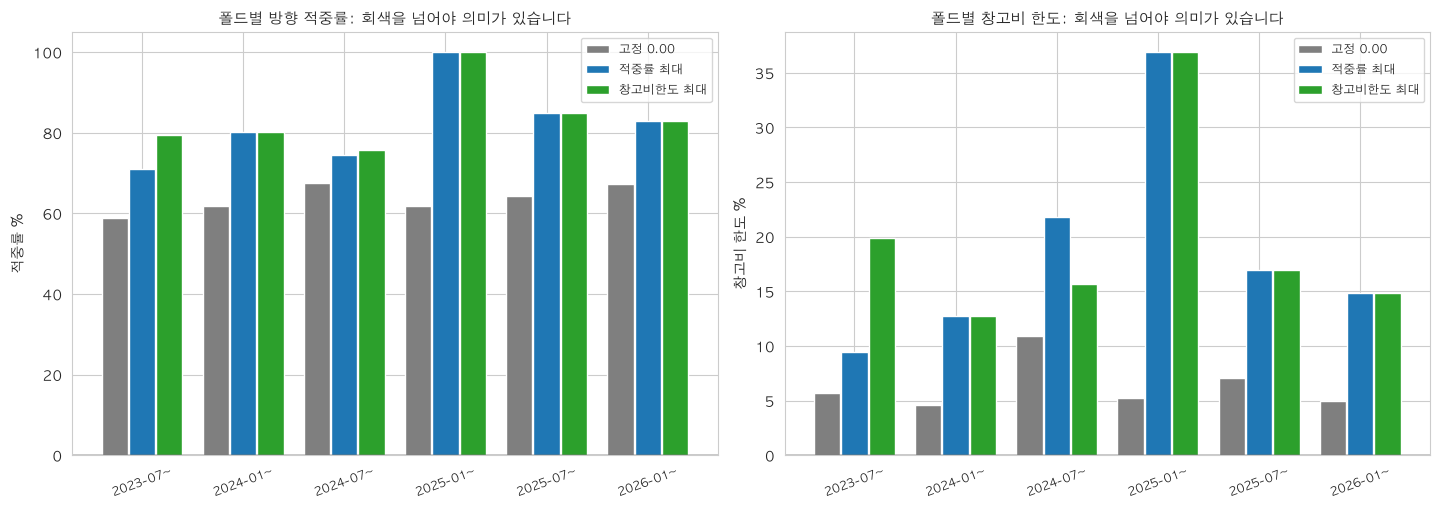

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
ORDER = ["고정 0.00", "적중률 최대", "창고비한도 최대"]
C3 = ["tab:gray", "tab:blue", "tab:green"]

for ax, col, title in (
        (axes[0], "적중률 %", "폴드별 방향 적중률"),
        (axes[1], "창고비 한도 %", "폴드별 창고비 한도")):
    p = wf.pivot(index="폴드", columns="방식", values=col)[ORDER]
    x = np.arange(len(p))
    for i, (m, c) in enumerate(zip(ORDER, C3)):
        ax.bar(x + (i - 1) * 0.27, p[m], width=0.26, color=c, label=m)
    ax.set_xticks(x)
    ax.set_xticklabels(p.index, fontsize=8.5, rotation=20)
    ax.set_ylabel(col)
    ax.set_title(title + ": 회색을 넘어야 의미가 있습니다", fontsize=11)
    ax.legend(fontsize=8.5)
    ax.axhline(0, color="black", lw=1)

plt.tight_layout()
plt.show()

## 8. 결론

### 한 줄 요약

**모델은 자기가 언제 맞힐지 압니다.** 확신하는 날만 고르면 적중률이 62.8%에서
72.1%로 오르고, 그 임계값은 **결과를 안 보고도 미리 정할 수 있습니다.**

### 가설 판정

| 가설 | 내용 | 결과 | 판정 |
|---|---|---|---|
| **H1** | 확신할수록 잘 맞힌다 | 확률 0.9 이상 97.3% · 0.1 이하 86.2% · 0.5 근처 52.3% | **확인됨** |
| **H2** | 확신하는 날만 쓰면 건당 수익성이 오른다 | 창고비 한도 4.80% → 10.12% (실행가능) | **확인됨** |
| **H3** | 11번의 실패와 다르다 | 같은 커버리지에서 확률 컷이 회귀 크기 컷과 사실상 동률 | **반증됨** |

### 예측이 빗나갔습니다

작업 전 예측은 "62.8%에서 2~3%p 오르고 70%는 어렵다"였습니다.

| 확신도 임계값 | 남는 날 | 커버리지 | 적중률 | 12번 대비 |
|---|---|---|---|---|
| 0.00 (12번) | 15,762 | 100.0% | 62.8% | — |
| 0.15 | 7,163 | 45.4% | 70.4% | +7.6%p |
| **0.20** | **5,080** | **32.2%** | **72.1%** | **+9.3%p** |
| 0.30 | 1,716 | 10.9% | 76.5% | +13.7%p |

예측의 3배 넘게 올랐고 70%도 넘겼습니다. **확률은 그냥 임계값 재료가 아니라
신뢰도 정보를 담고 있었습니다.** 보정 곡선도 이를 뒷받침합니다: 확률 0.7~0.8
구간에서 실제로 72.1% 가 올랐고 0.8~0.9 구간에서 78.4% 가 올랐습니다.

### H3는 반증됐고, 그게 더 중요합니다

11번 방식(회귀 예측 크기로 날 고르기)을 **같은 커버리지**에서 나란히 놓으니
차이가 거의 없었고, 많이 자를수록 오히려 회귀 크기가 앞섰습니다.

| 커버리지 | 확률 컷 | 회귀 크기 컷 | 차이 |
|---|---|---|---|
| 61.5% | 67.8% | 66.6% | +1.2%p |
| 32.2% | 72.1% | 72.2% | -0.1%p |
| 10.9% | 76.5% | 79.1% | **-2.6%p** |

**그러면 11번은 왜 실패했나**: 11번은 같은 신호를 **다른 척도**로 쟀습니다.
모델과 naive 중 무엇을 쓸지 MAPE 로 갈랐고, 여기서는 방향 적중률과 판매단가로
쟀습니다. 신호는 처음부터 있었고 척도가 그걸 가리고 있었습니다. 12번에서 얻은
교훈 4("척도를 바꾸면 보이는 게 달라진다")가 한 번 더 확인된 셈입니다.

**실무적으로는**: 확신도를 꼭 분류 확률로 잴 필요가 없습니다. 회귀 모델만
돌리는 구성이라면 예측 크기로 잘라도 같은 효과를 봅니다.

### 돈으로 보면: 적게 넣고 적게 법니다

출하 전량을 오늘 팔면 1,000만 원이라고 놓았을 때입니다.

| 대상 | 방식 | 창고에 넣은 물건값 | 더 번 돈 = 쓸 수 있는 창고비 | 넣은 값 대비 |
|---|---|---|---|---|
| 실행 가능 14품목 | 다 넣기 | 433만 원 | 20.7만 원 | 4.8% |
| 실행 가능 14품목 | 확신한 날만 | 146만 원 | 14.7만 원 | 10.1% |
| 중간지대 4품목 | 다 넣기 | 508만 원 | 44.1만 원 | 8.7% |
| **중간지대 4품목** | **확신한 날만** | **210만 원** | **33.9만 원** | **16.2%** |

**상충이 분명합니다.** 확신한 날만 고르면 창고에 넣는 양이 3분의 1로 줄고 버는
총액도 줄지만, 넣은 물량 대비 여유는 두 배가 됩니다. **창고가 비싸고 좁으면
확신한 날만, 창고가 놀고 있으면 다 넣는 쪽**이 유리합니다. 어느 쪽인지는 데이터가
아니라 현장 사정이 정합니다.

### 정직한 평가: 임계값은 미리 정할 수 있습니다

04·11번에서 실패한 것이 여기서는 됩니다. 이전 폴드만 보고 임계값을 정해 다음
폴드에 적용한 6폴드 평균입니다.

| 방식 | 고른 임계값 | 남는 날 | 커버리지 | 적중률 | 더 받은 돈 | 창고비 한도 |
|---|---|---|---|---|---|---|
| 고정 0.00 | 0.00 | 2,293 | 100.0% | 63.6% | 2.95% | 6.42% |
| 창고비한도 최대 | 0.31 | 292 | 12.7% | **83.8%** | 1.13% | **19.51%** |
| 적중률 최대 | 0.32 | 215 | 9.2% | 82.3% | 0.91% | 18.80% |

**04·11번과 갈린 이유**: 그때는 "이 품목은 모델, 저 시기는 naive" 처럼 **무엇을
쓸지**를 갈랐고, 여기서는 **언제 행동할지**를 갭니다. 앞의 둘은 어느 쪽을 골라도
행동을 하지만, 이번 규칙은 애매하면 **아무것도 안 합니다**. 기권이 선택지에
있다는 게 차이입니다.

### 한계

- **폴드별 표본이 얇습니다.** 임계값 0.31 이면 폴드당 평균 292일이고, 2025 상반기
  폴드는 **29일**뿐인데 적중률 100% 로 나왔습니다. 그 칸은 신뢰할 수 없습니다.
- **확신하는 날이 어디에 몰리는지 안 봤습니다.** 특정 품목·특정 달에 쏠려 있으면
  나머지 기간에는 쓸 수가 없습니다. 이건 다음에 확인해야 합니다.
- **창고비 실측치가 여전히 없습니다.** 이 문서는 "얼마까지 쓸 수 있나"만 답합니다.
- **감모와 등급 하락은 안 들어갔습니다.** 둘 다 한도를 깎는 방향이라 위 숫자는
  낙관적인 상한입니다.
- **어느 임계값을 채택할지는 정하지 않았습니다.** 창고 사정에 달린 문제입니다.

### 다음에 해볼 만한 것

1. **확신하는 날의 분포를 본다**: 품목 × 월로 쪼개 쏠림이 있는지 확인합니다.
   쏠려 있으면 "연중 12.7%" 가 아니라 "특정 두 달에 몰빵"이라 운영이 달라집니다.
2. **중간지대 4품목 전용 모델**: 지금은 19품목을 한 모델로 학습합니다. 넷만
   따로 학습하면 16.2% 가 더 오를 수 있습니다.
3. **창고비 실측치**: 저온저장고 7거래일 운영비가 물건값의 16% 아래인지가
   중간지대 전략의 성패를 가릅니다.